In [103]:
import numpy as np #Numerical operations, arrays, and matrices
import pandas as pd #Data manipulation


Columns name


In [104]:
df=pd.read_csv('datasets/changed/data_news_1.csv')
print(df.columns)


Index(['type_of_news', 'title', 'text', 'source'], dtype='object')


In [105]:
null_rows = df[df.isnull().any(axis=1)]
print(null_rows)


    type_of_news                                              title  \
105         Fake  Hillary Denies She and Obama Founded ISIS…Then...   
112         Fake  CNN’s Post-Debate Rigged Poll Busted…Here Are ...   
114         Fake  Homosexual Thinks Muslims Will Accept Him, Ins...   
115         Fake  REVEALED! Minnesota Mall Attacker ID'd As One ...   
118         Fake  BREAKING: WikiLeaks Releases Proof Hillary Lie...   
138         Fake  ALERT: Police Pull Over ‘Islamic Refugee,’ Hor...   
139         Fake  CNN’s Post-Debate Rigged Poll Busted…Here Are ...   
149         Fake  Surgeon General warns: Drinking every time Tru...   

                                                  text source  
105  It was late one night in the White House when ...    NaN  
112  We’re shocked — SHOCKED — to learn that CNN’s ...    NaN  
114  Once again, the “religion of peace” has proven...    NaN  
115  A man wearing a security uniform entered a mal...    NaN  
118  The FBI has issued a letter stating

Replacing source NaN with the unknown source

In [ ]:
df['source'] = df['source'].fillna('Unknown')


title     0
text      0
source    0
dtype: int64


In [120]:
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.model_selection import train_test_split
from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score, classification_report

import nltk
from nltk.stem import WordNetLemmatizer
from nltk.corpus import stopwords
import string

nltk.download('punkt')
nltk.download('wordnet')
nltk.download('omw-1.4')
nltk.download('stopwords')

lemmatizer = WordNetLemmatizer()
stop_words = set(stopwords.words('english'))

# Preprocessing function
def preprocess(text):
    tokens = nltk.word_tokenize(text.lower())
    tokens = [t for t in tokens if t.isalpha()]  # remove punctuation/numbers
    tokens = [lemmatizer.lemmatize(t) for t in tokens if t not in stop_words]
    return ' '.join(tokens)


# Step 1: Combine and preprocess
df['combined'] = df['title'] + ' ' + df['text'] + ' ' + df['source']
print(df['combined'].head)
df['combined_clean'] = df['combined'].apply(preprocess)

# Step 2: Vectorize cleaned text
vectorizer = CountVectorizer()
X = vectorizer.fit_transform(df['combined_clean'])
y = df['type_of_news']

# Step 3: Train/test split
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.5, random_state=42, stratify=y)

# Step 4: Train Naive Bayes
nb_model = MultinomialNB()
nb_model.fit(X_train, y_train)

# Step 5: Evaluate
from sklearn.metrics import accuracy_score, classification_report
y_pred = nb_model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred, zero_division=0))


<bound method NDFrame.head of 0      Another Terrorist Attack in NYC…Why Are we STI...
1      Donald Trump: Drugs a 'Very, Very Big Factor' ...
2      Obama To UN: ‘Giving Up Liberty, Enhances Secu...
3      Trump vs. Clinton: A Fundamental Clash over Ho...
4      President Obama Vetoes 9/11 Victims Bill, Sett...
                             ...                        
177    Hillary’s TOP Donor Country Just Auctioned Off...
178    Cavuto Just Exposed Lester Holt's Lies During ...
179    The AP, In 2004, Said Your Boy Obama Was BORN ...
180    People Noticed Something Odd About Hillary's O...
181    People Noticed Something Odd About Hillary’s O...
Name: combined, Length: 182, dtype: object>


[nltk_data] Downloading package punkt to
[nltk_data]     /Users/siddharthapudasaini/nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package wordnet to
[nltk_data]     /Users/siddharthapudasaini/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!
[nltk_data] Downloading package omw-1.4 to
[nltk_data]     /Users/siddharthapudasaini/nltk_data...
[nltk_data]   Package omw-1.4 is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/siddharthapudasaini/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


LookupError: 
**********************************************************************
  Resource [93mpunkt_tab[0m not found.
  Please use the NLTK Downloader to obtain the resource:

  [31m>>> import nltk
  >>> nltk.download('punkt_tab')
  [0m
  For more information see: https://www.nltk.org/data.html

  Attempted to load [93mtokenizers/punkt_tab/english/[0m

  Searched in:
    - '/Users/siddharthapudasaini/nltk_data'
    - '/Users/siddharthapudasaini/nlp/Natural_Language/.venv/nltk_data'
    - '/Users/siddharthapudasaini/nlp/Natural_Language/.venv/share/nltk_data'
    - '/Users/siddharthapudasaini/nlp/Natural_Language/.venv/lib/nltk_data'
    - '/usr/share/nltk_data'
    - '/usr/local/share/nltk_data'
    - '/usr/lib/nltk_data'
    - '/usr/local/lib/nltk_data'
**********************************************************************


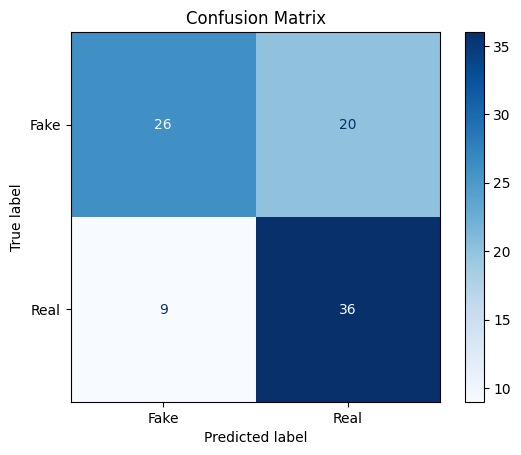

In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Step 6: Confusion Matrix
cm = confusion_matrix(y_test, y_pred, labels=['Fake', 'Real'])

# Plot the confusion matrix
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Fake', 'Real'])
disp.plot(cmap=plt.cm.Blues)
plt.title("Confusion Matrix")
plt.show()

In [ ]:
user_title = input("Enter news title: ")
user_text = input("Enter news text: ")
user_source=input("Enter news source: ")
user_combined = user_title + ' ' + user_text
user_vector = vectorizer.transform([user_combined])
prediction = nb_model.predict(user_vector)
print(prediction)


['Real']
